In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
# make train/test/val split indices for R&D dataset bkg
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    nevents = np.count_nonzero(mask)
indices = np.arange(nevents)
train_idx, test_idx = train_test_split(indices,train_size=0.5,random_state=76512)
test_idx, val_idx = train_test_split(test_idx,train_size=0.5,random_state=93014)
with h5py.File(base+"rd/RD/split_indices.h5","w") as fout:
    fout.create_dataset("train_inds",data=train_idx)
    fout.create_dataset("test_inds",data=test_idx)
    fout.create_dataset("val_inds",data=val_idx)

In [4]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    nev = len(labels_b1)
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    b1_sig = np.concatenate([fp_b1[v][()][labels_b1==1].reshape(-1,1) for v in fitvars],axis=1)
    n_sample_train = int(np.count_nonzero(labels_b1==1)*len(b1_train)/np.count_nonzero(labels_b1==0))
    n_sample_test = int(np.count_nonzero(labels_b1==1)*len(b1_test)/np.count_nonzero(labels_b1==0))
    b1_sig_inj = b1_sig[np.random.choice(len(b1_sig),size=n_sample_train+n_sample_test,replace=False)]
    b1_train = np.concatenate((b1_train,b1_sig_inj[:n_sample_train]),axis=0)
    np.random.shuffle(b1_train)
    b1_test = np.concatenate((b1_test,b1_sig_inj[n_sample_train:]),axis=0)
    np.random.shuffle(b1_test)
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]

# Train flows

In [7]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_PythRDtoContamBB1_jets12",rd_train,rd_test,b1_train,b1_test,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.272137122154236, p = 122: 100%|██████████| 500/500 [01:37<00:00,  5.14it/s] 


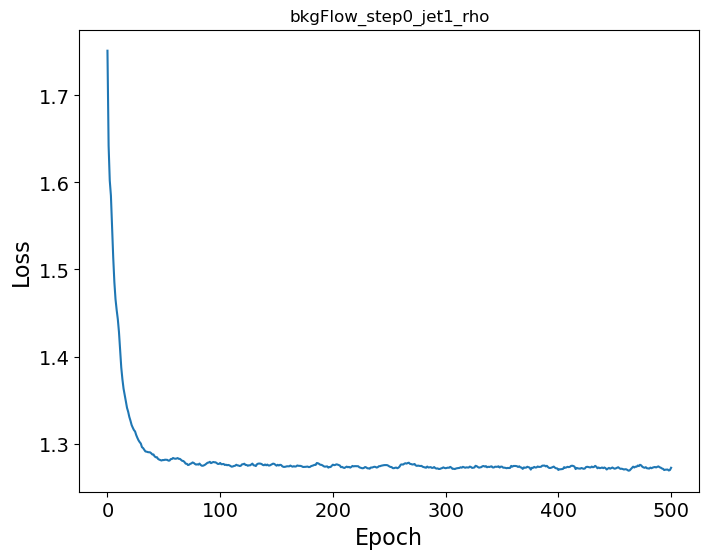

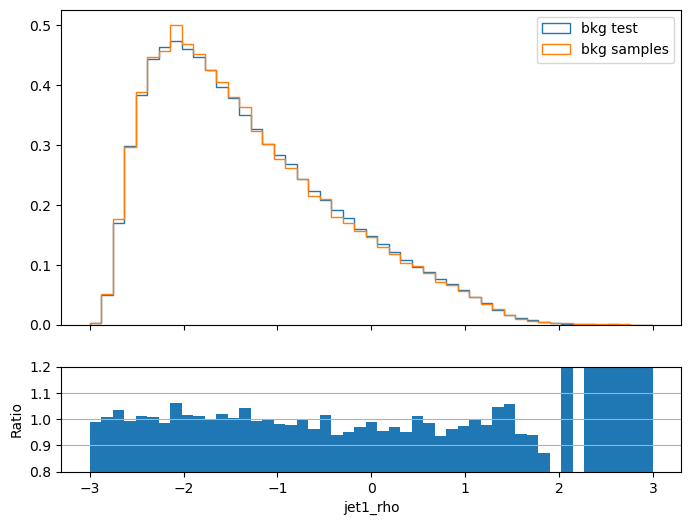

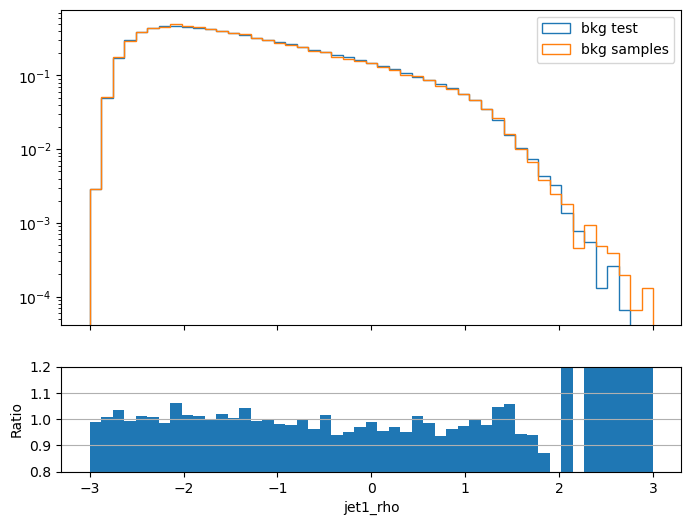

In [14]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_jet1_rho


Loss: 1.3292918241024017, p = 8: 100%|██████████| 500/500 [01:37<00:00,  5.13it/s]  


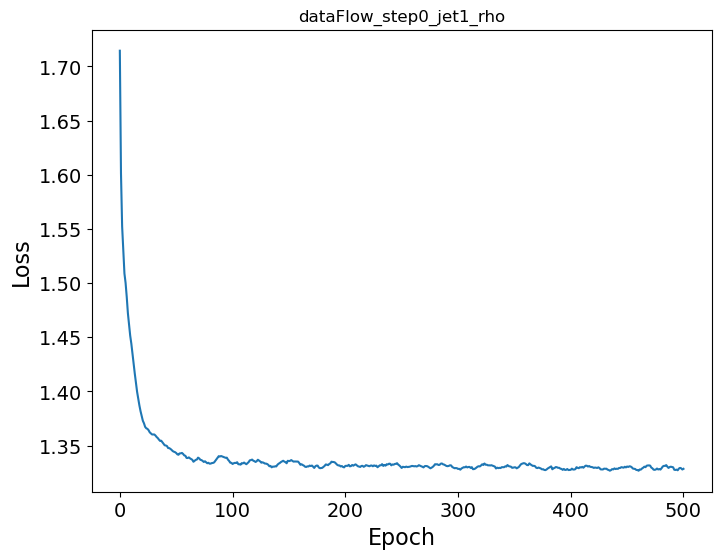

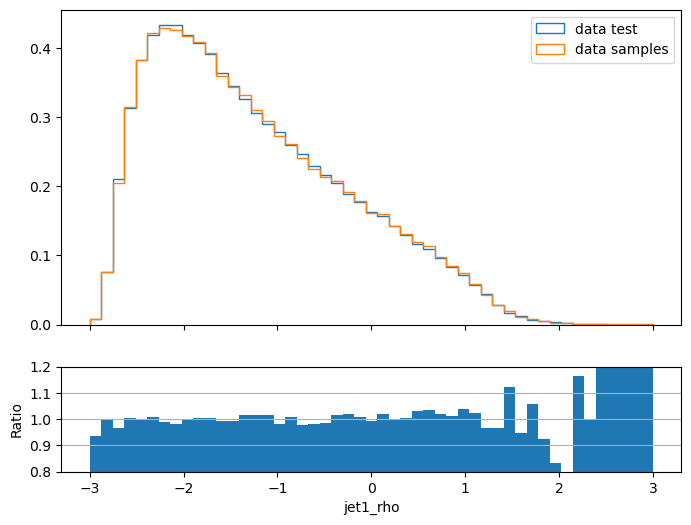

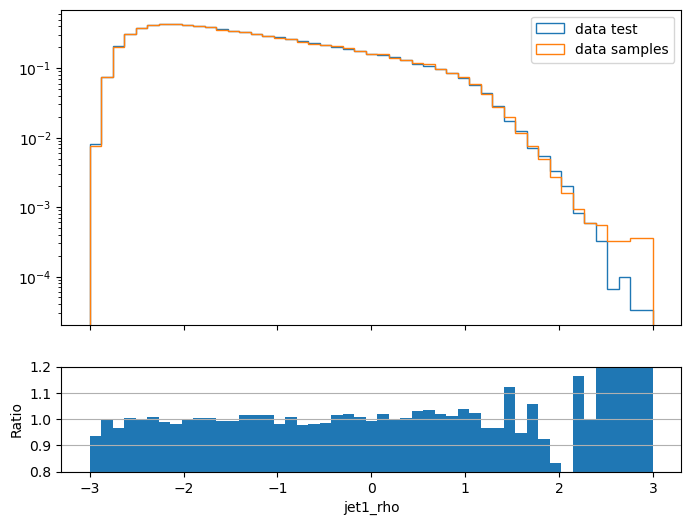

In [19]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:01<00:00, 15.61it/s]


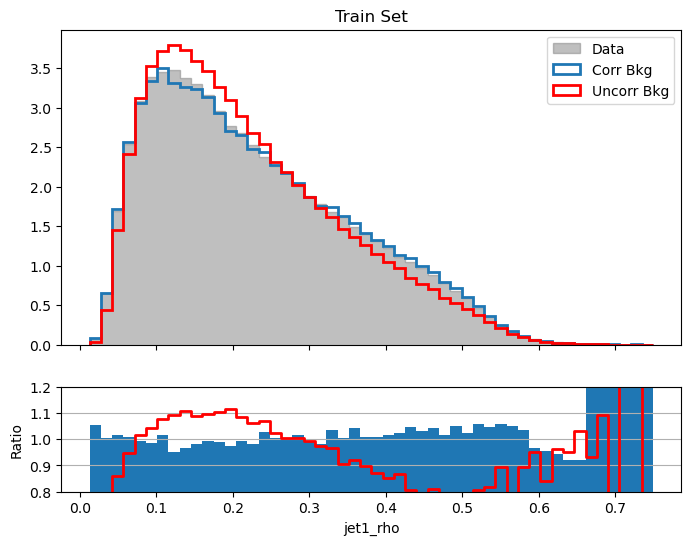

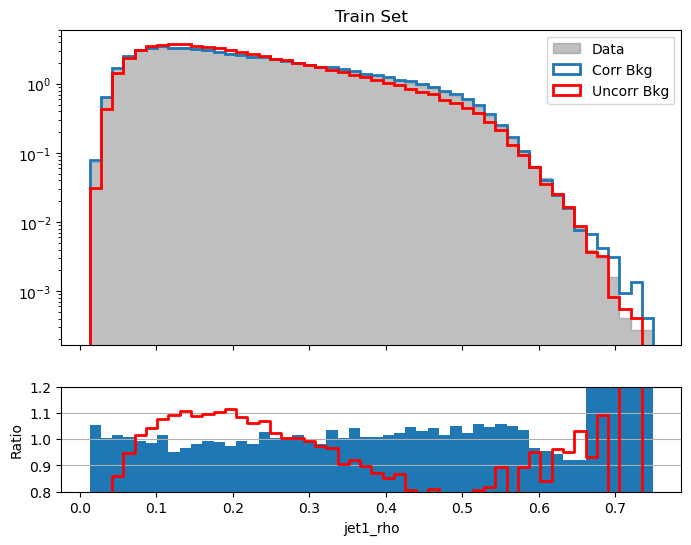

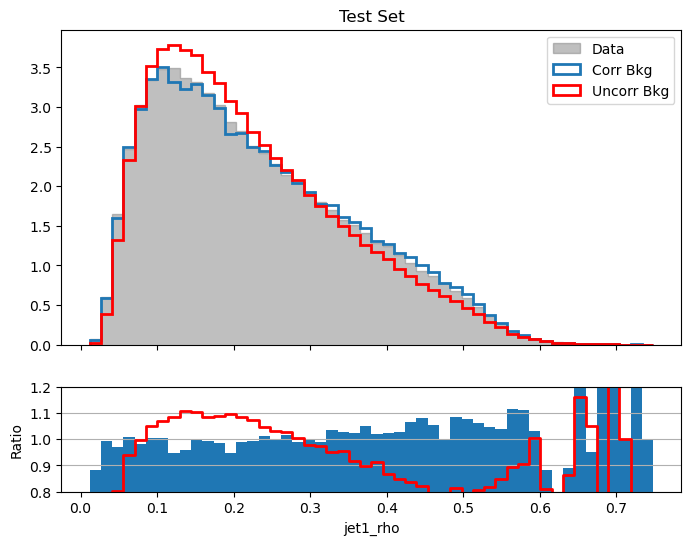

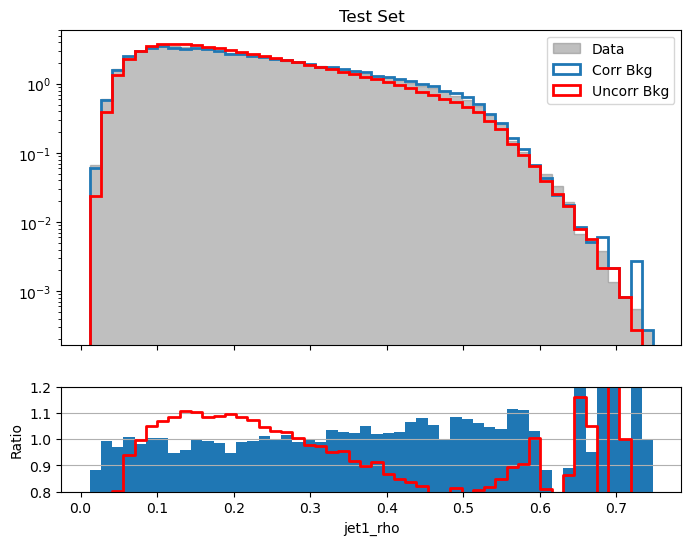

In [20]:
trainer.correctCurrent()
trainer.plotCurrent(50)

In [21]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.3534305894374847, p = 39: 100%|██████████| 500/500 [01:43<00:00,  4.83it/s]


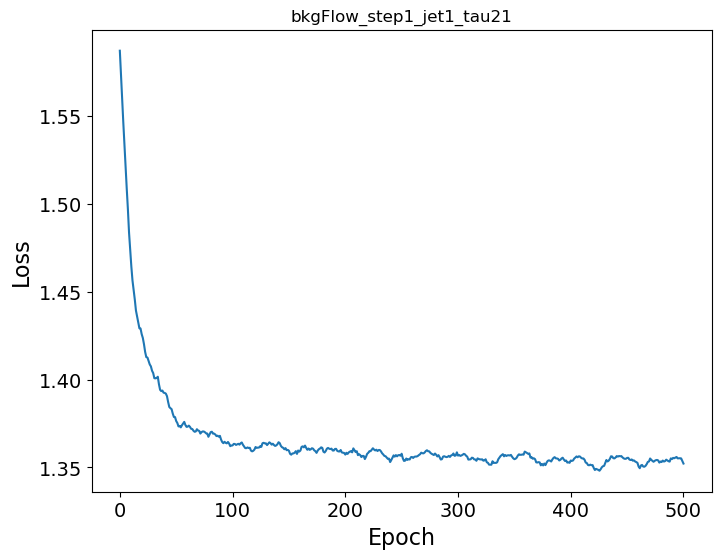

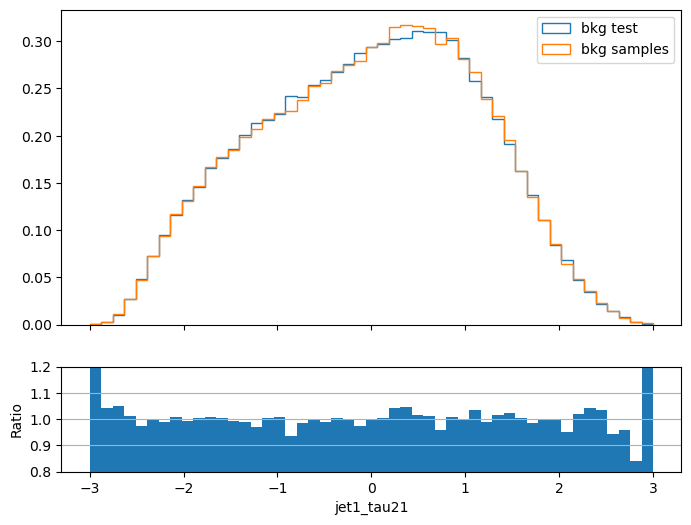

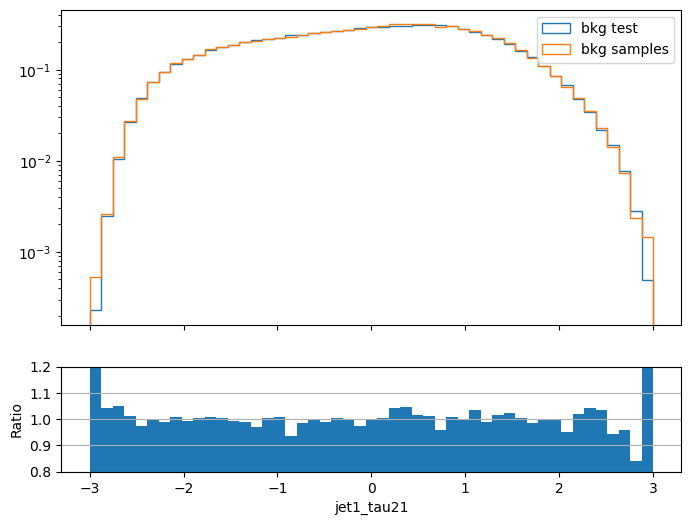

In [22]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3641441321372987, p = 23: 100%|██████████| 500/500 [01:43<00:00,  4.85it/s] 


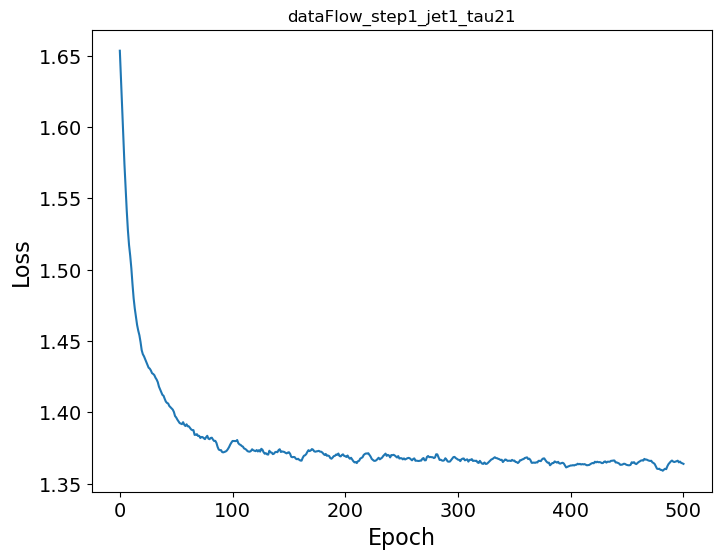

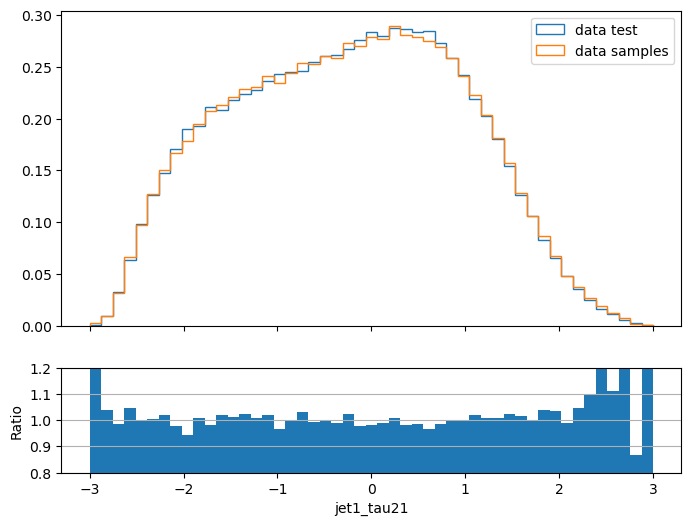

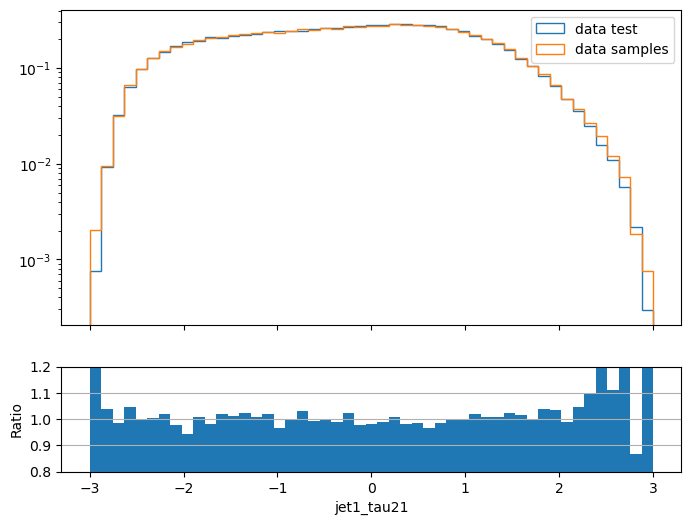

In [23]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:02<00:00, 10.60it/s]


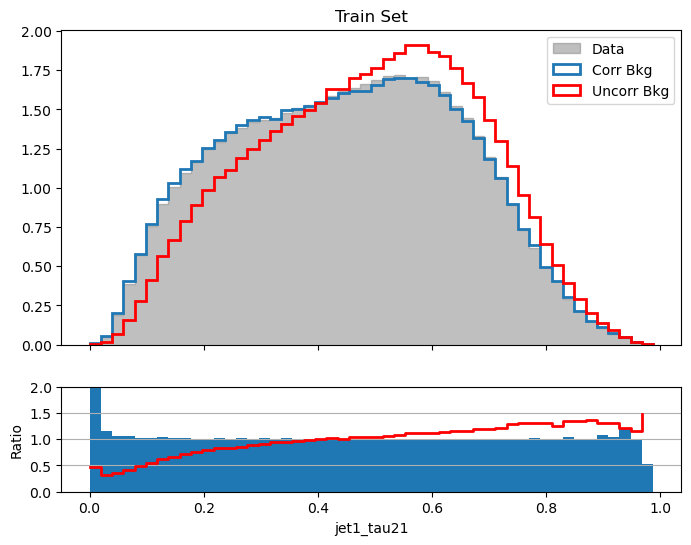

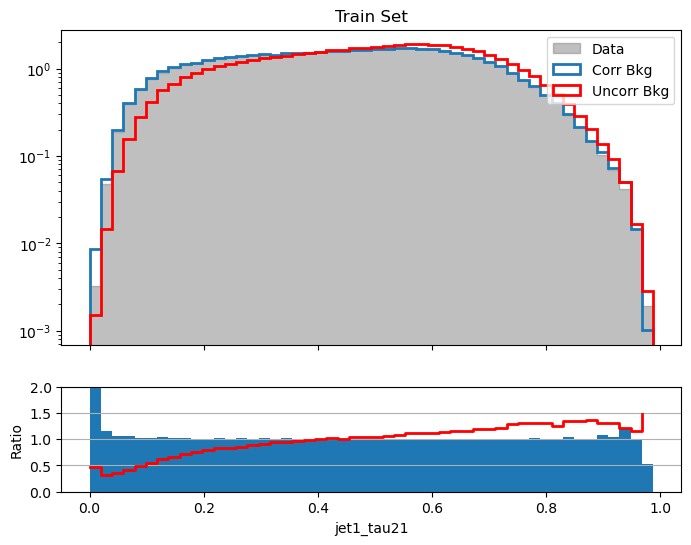

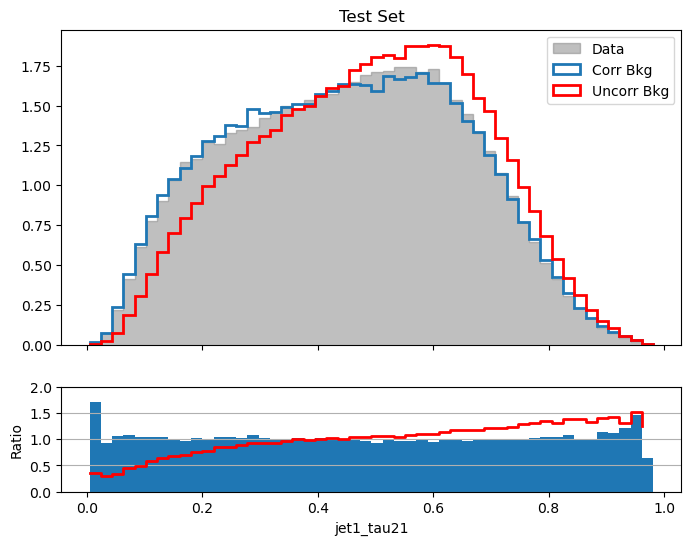

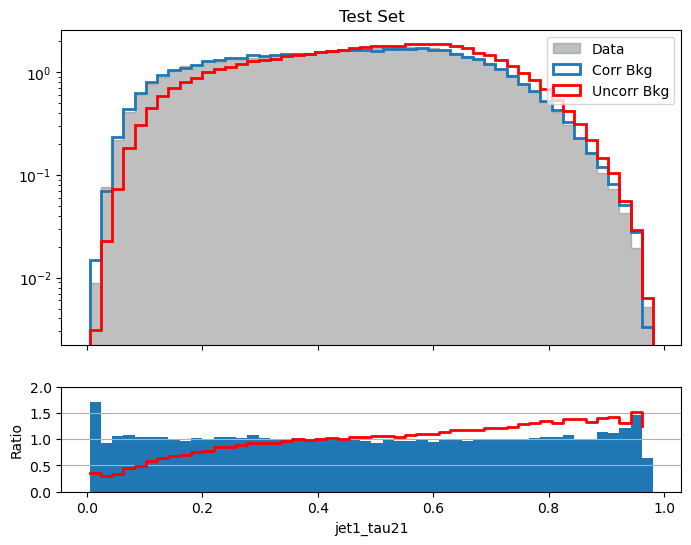

In [24]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [25]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.833613024353981, p = 61: 100%|██████████| 750/750 [02:38<00:00,  4.72it/s]  


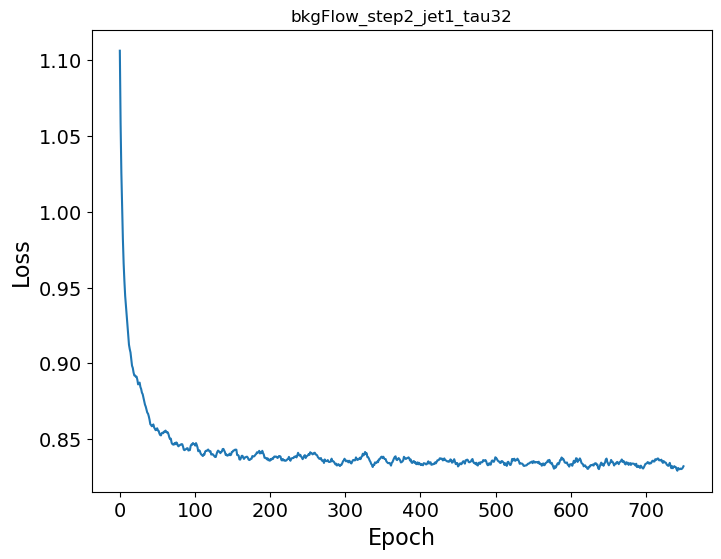

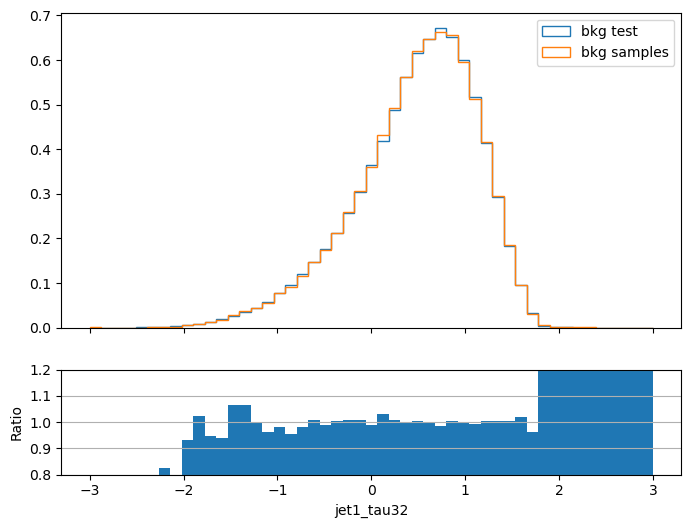

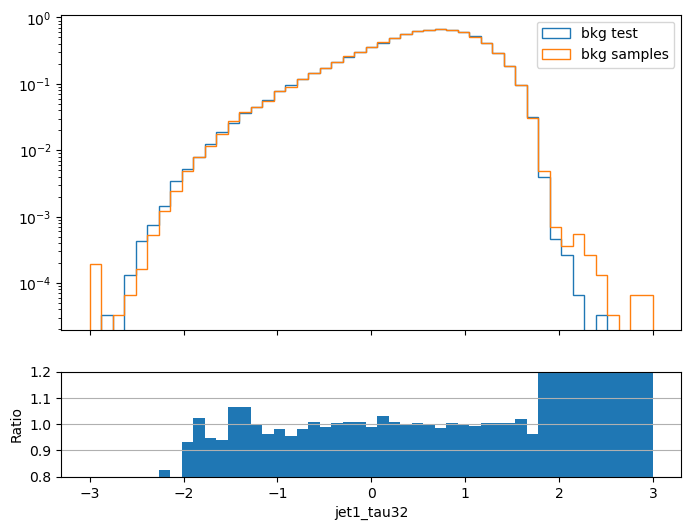

In [30]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_jet1_tau32


Loss: 0.8943772464990616, p = 337: 100%|██████████| 1000/1000 [03:25<00:00,  4.86it/s]


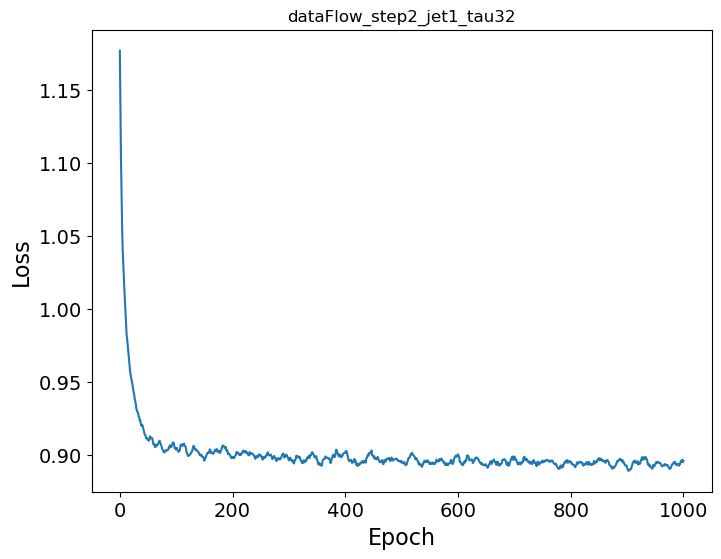

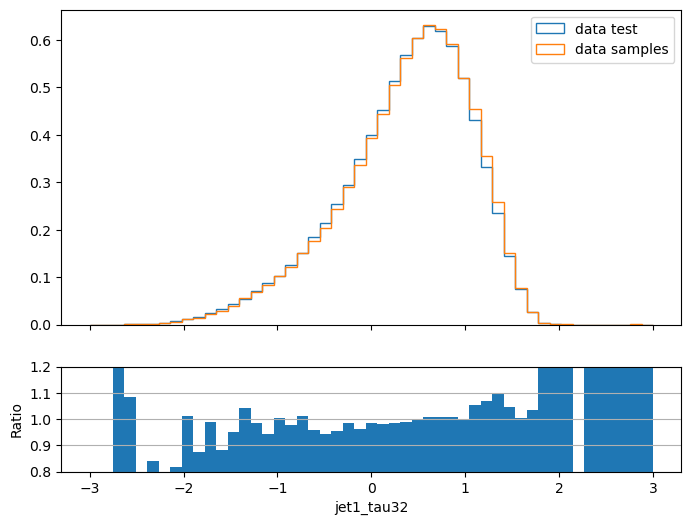

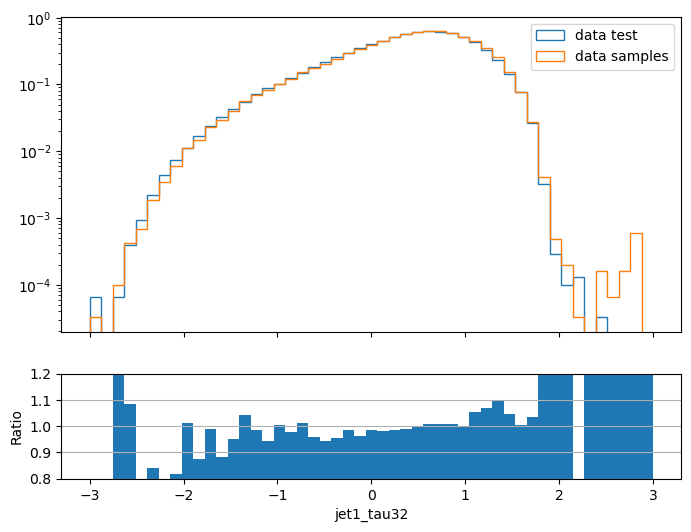

In [31]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:02<00:00,  9.49it/s]


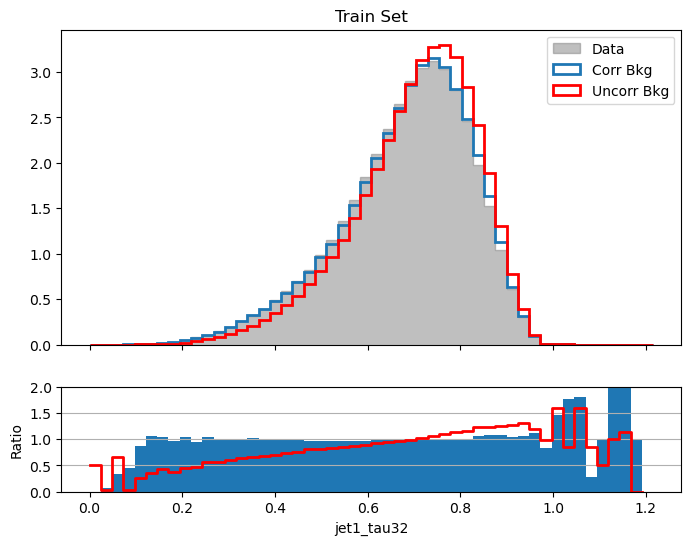

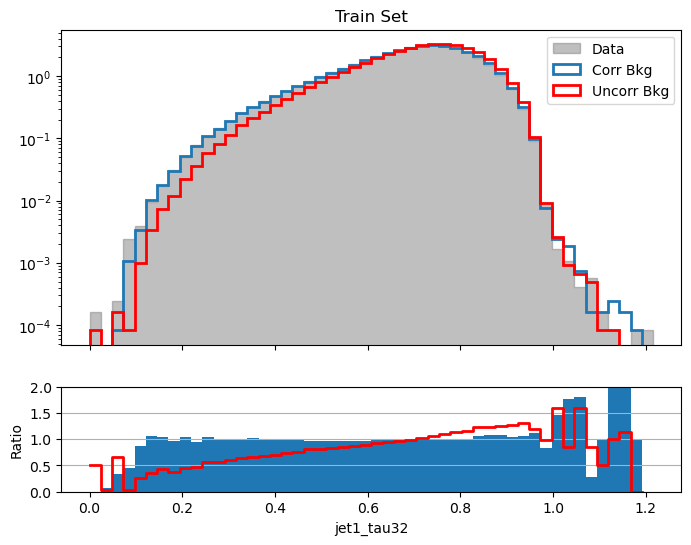

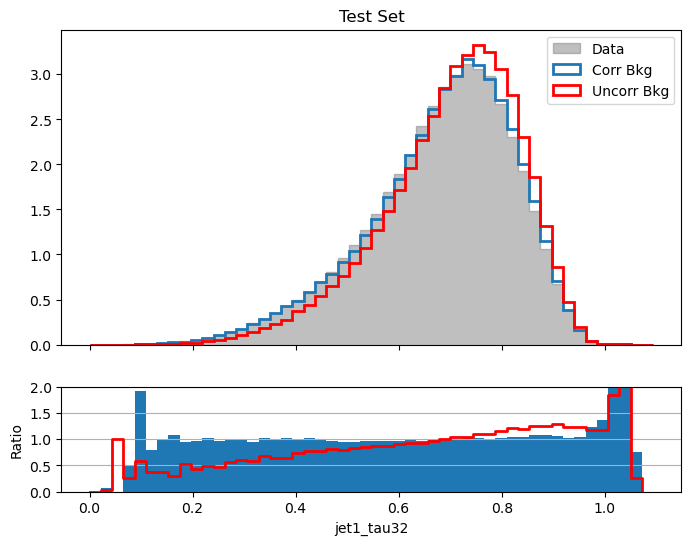

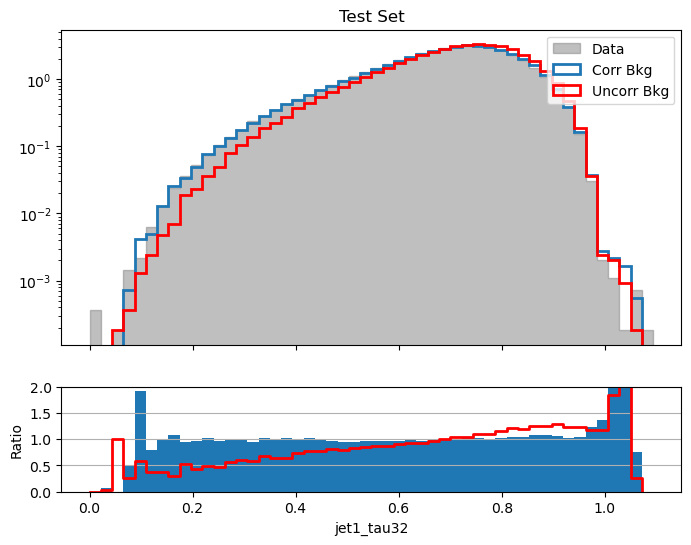

In [32]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [33]:
trainer.stepForward()

## jet1 tau43

In [48]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow bkgFlow_step4_jet2_rho


Loss: 0.4809688052535057, p = 61:  27%|██▋       | 401/1500 [01:06<03:02,  6.03it/s] 


KeyboardInterrupt: 

In [ ]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:00<00:00, 57.07it/s]


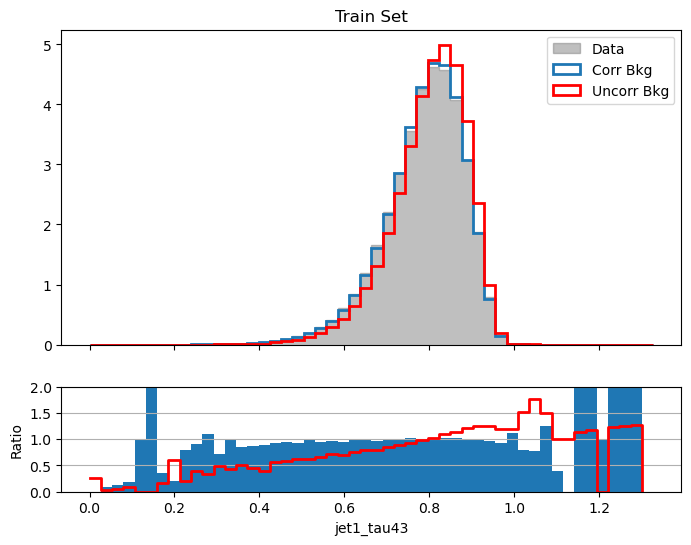

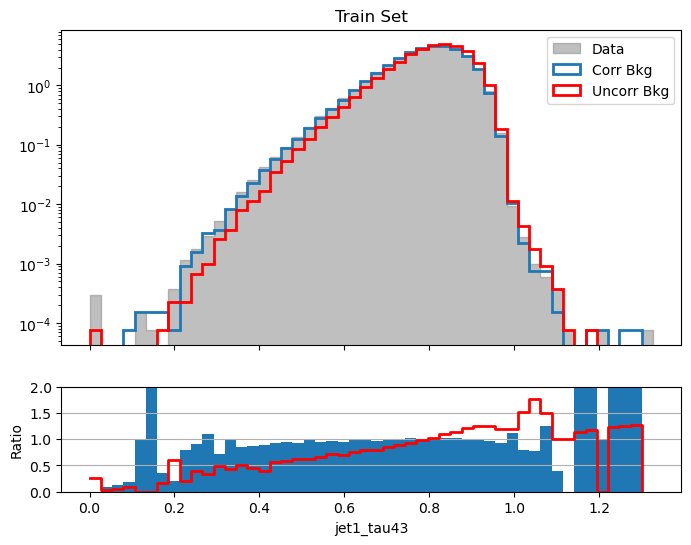

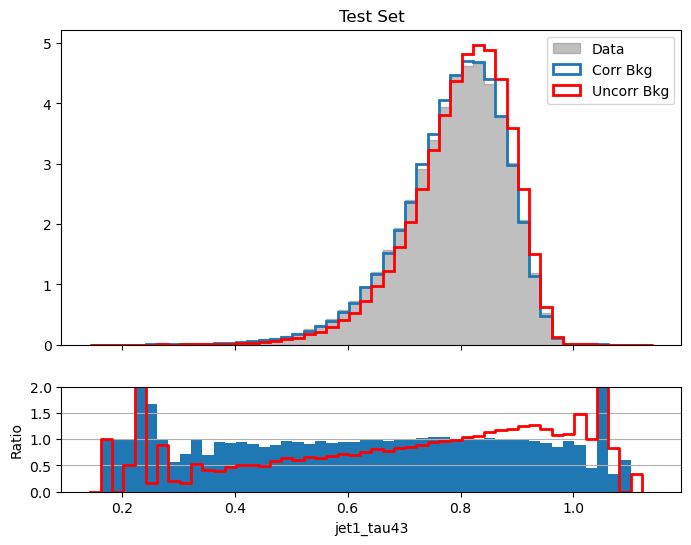

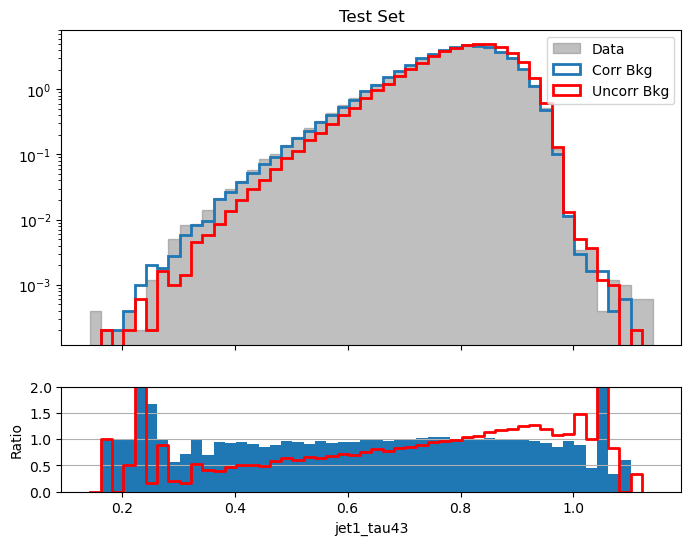

In [45]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [46]:
trainer.stepForward()

## jet2 rho

Training flow bkgFlow_step4_jet2_rho


Loss: 0.47381668865680693, p = 544: 100%|██████████| 1500/1500 [05:07<00:00,  4.87it/s]


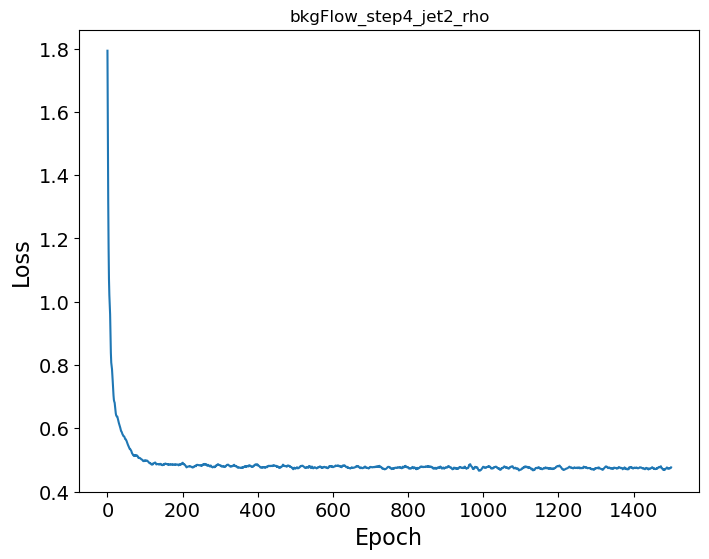

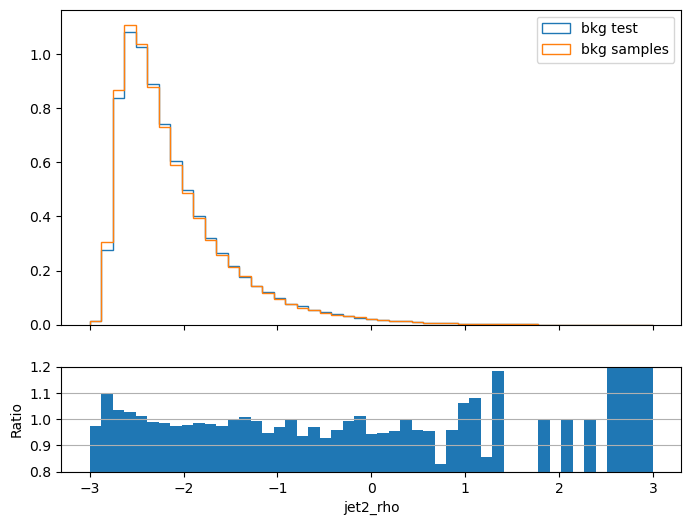

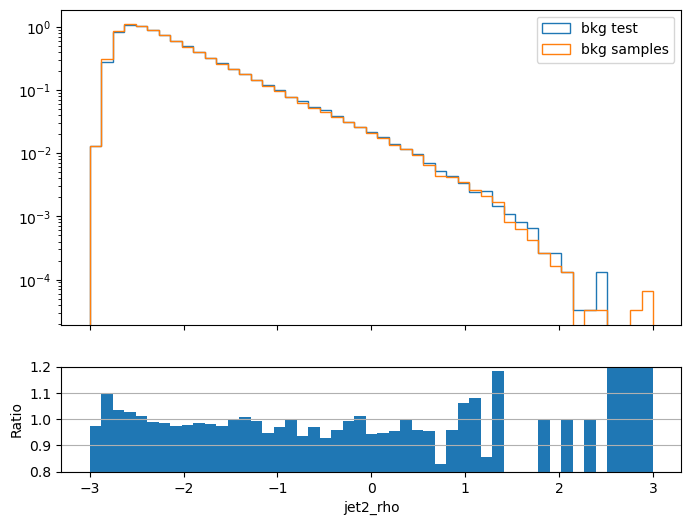

In [52]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_jet2_rho


Loss: 0.5417075496912003, p = 76: 100%|██████████| 1500/1500 [05:07<00:00,  4.87it/s] 


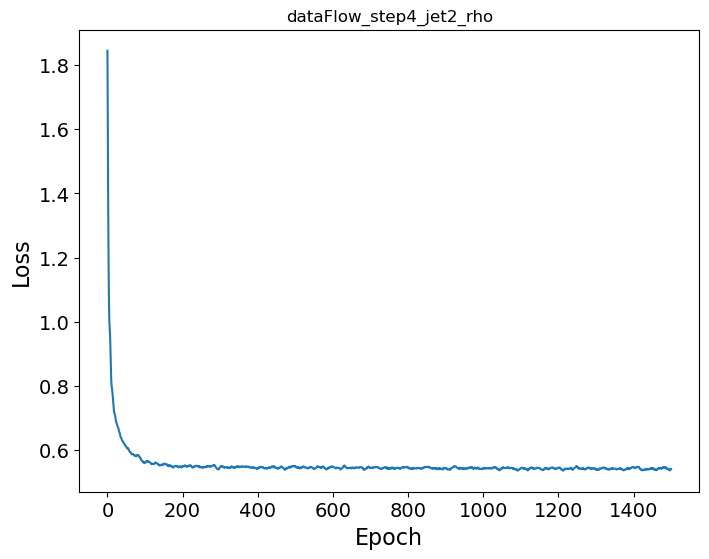

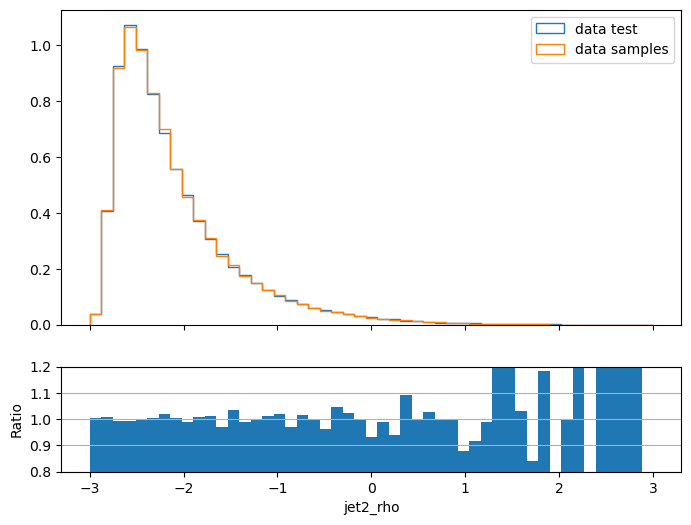

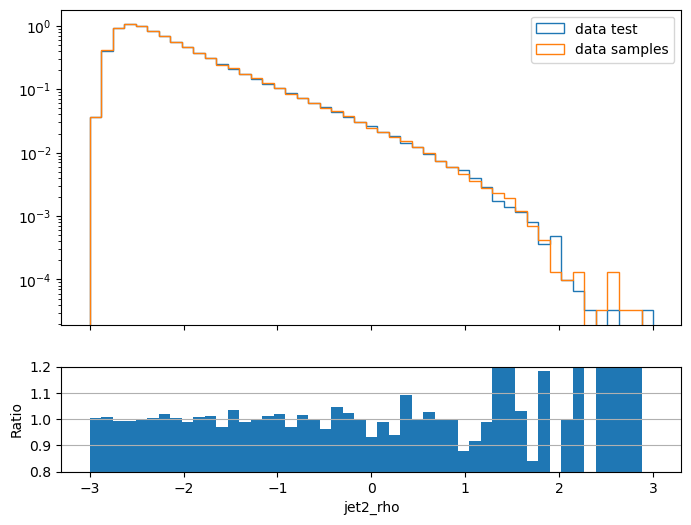

In [53]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:02<00:00,  9.38it/s]


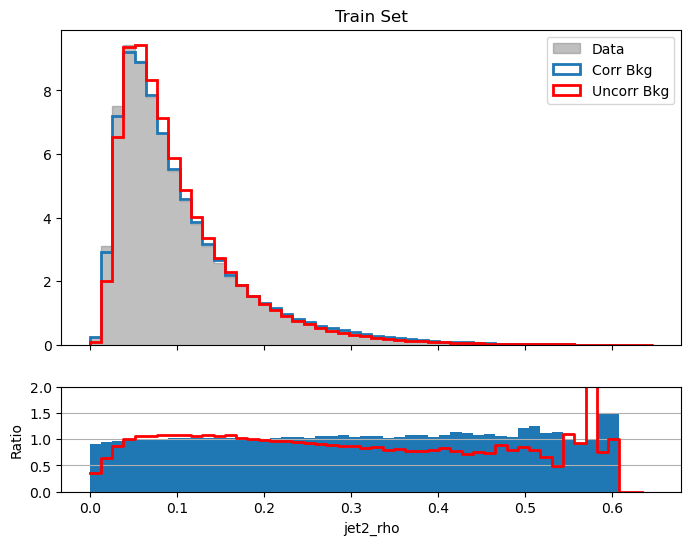

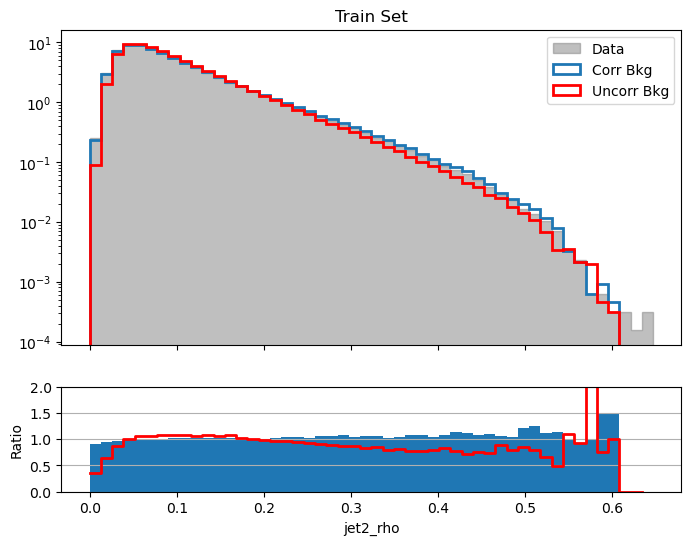

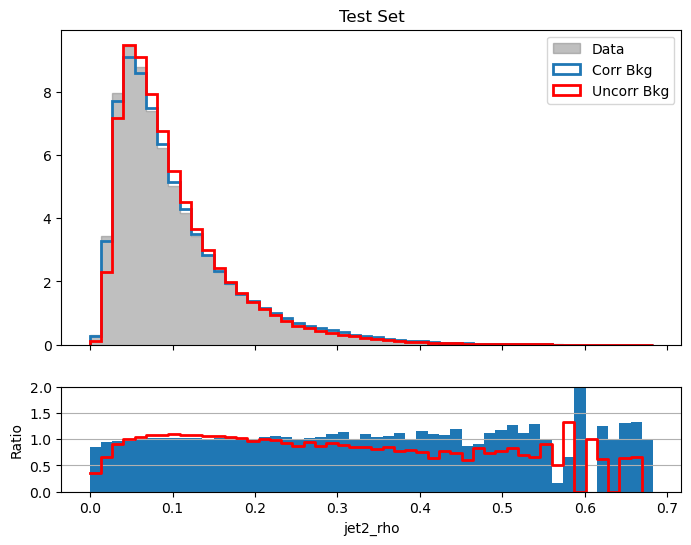

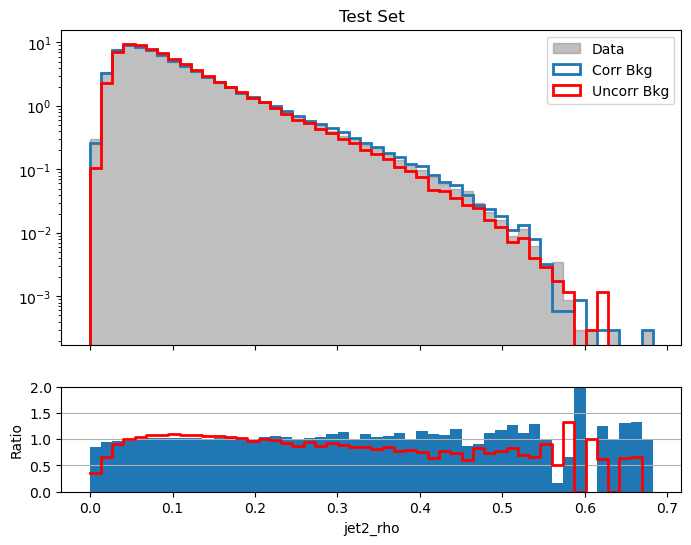

In [54]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [55]:
trainer.stepForward()

## jet2 tau21

Training flow bkgFlow_step5_jet2_tau21


Loss: 1.3658949112892151, p = 8: 100%|██████████| 1500/1500 [04:05<00:00,  6.10it/s]  


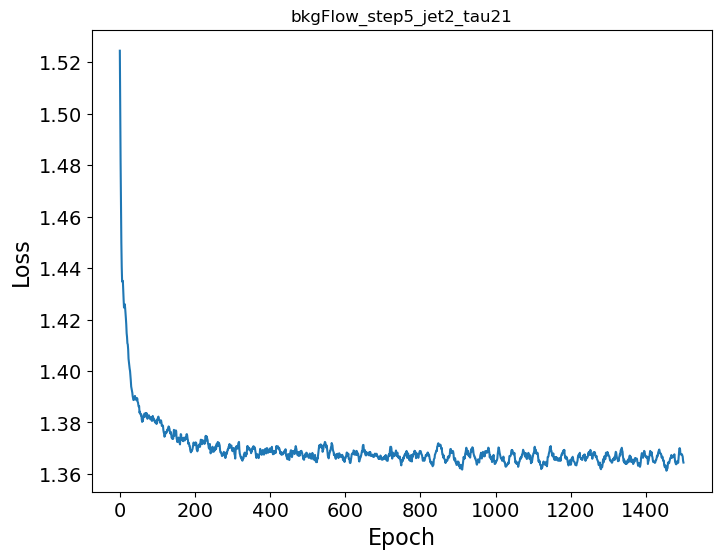

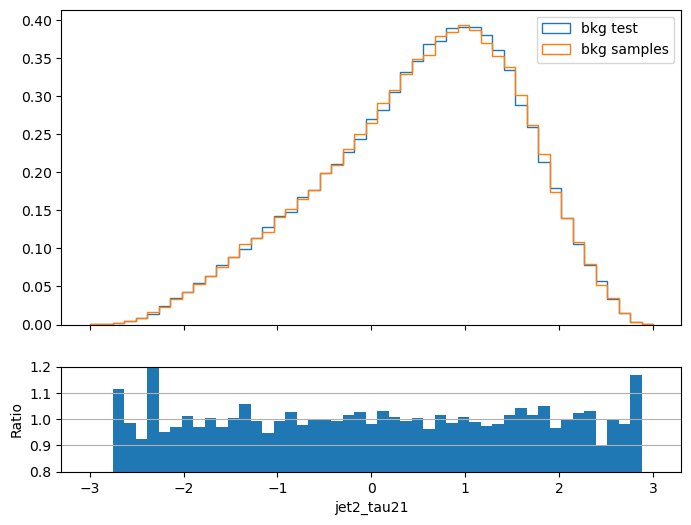

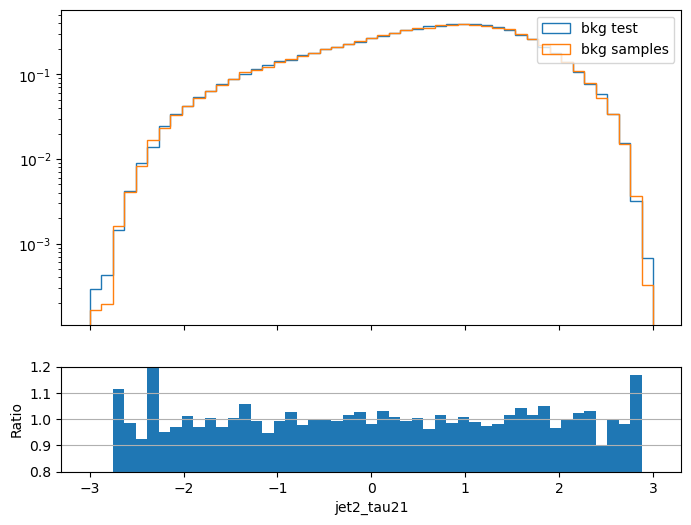

In [57]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_jet2_tau21


Loss: 1.4030871450901032, p = 48: 100%|██████████| 1500/1500 [04:07<00:00,  6.05it/s] 


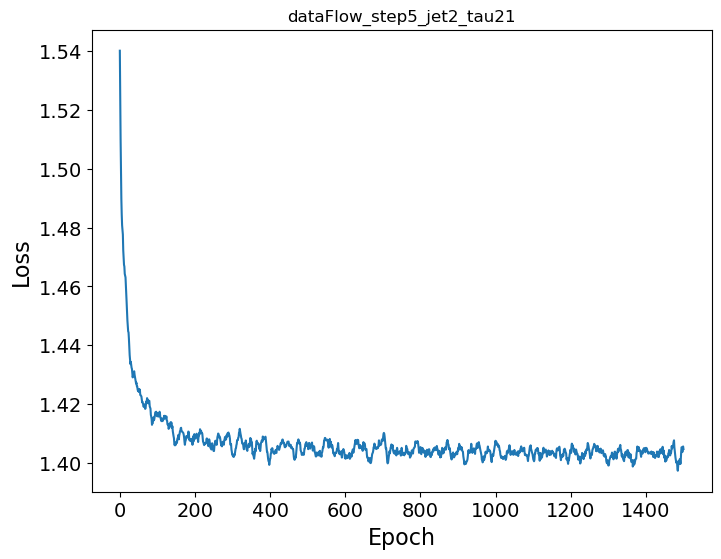

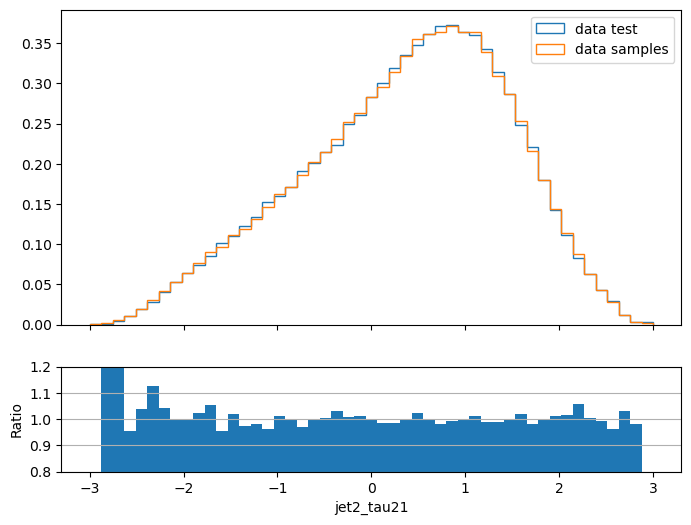

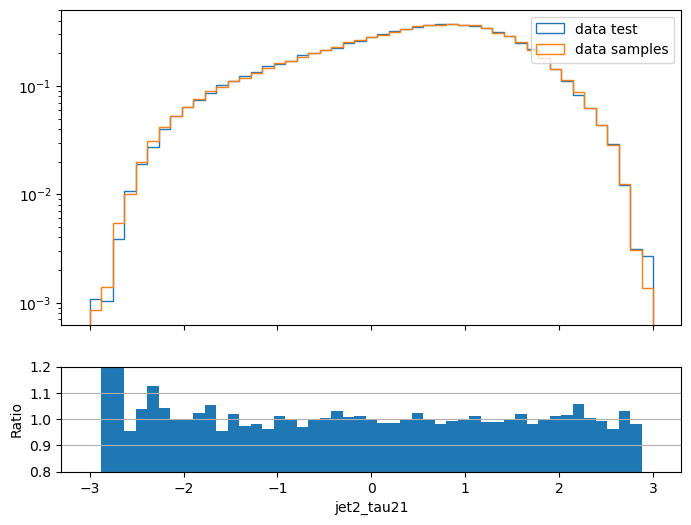

In [58]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:00<00:00, 46.02it/s]


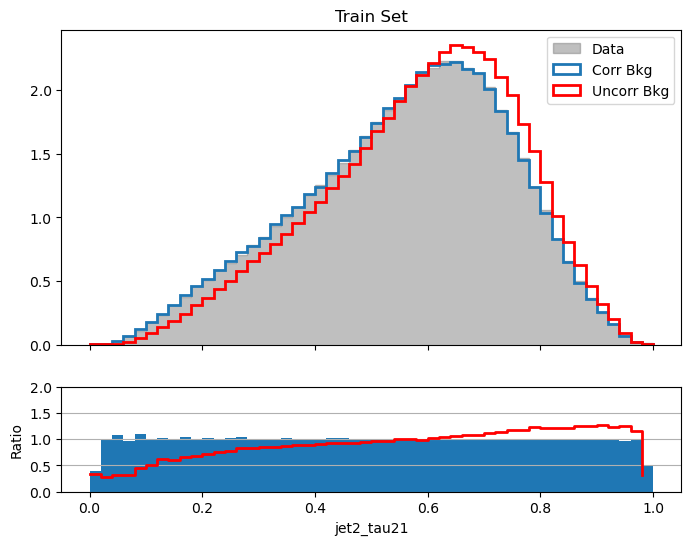

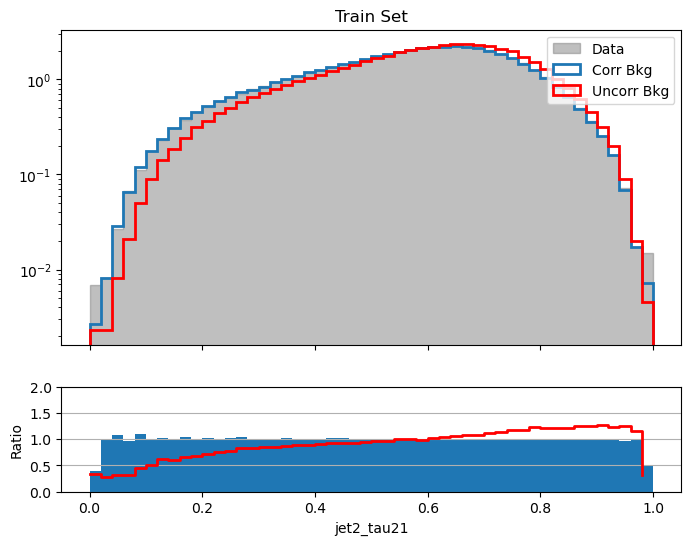

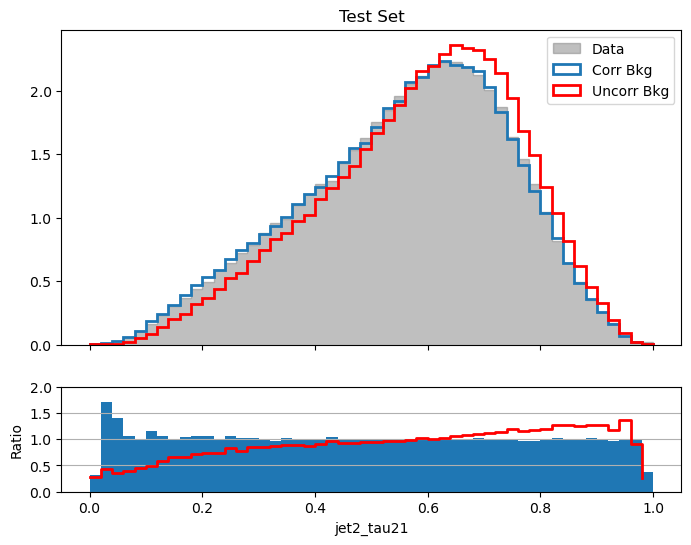

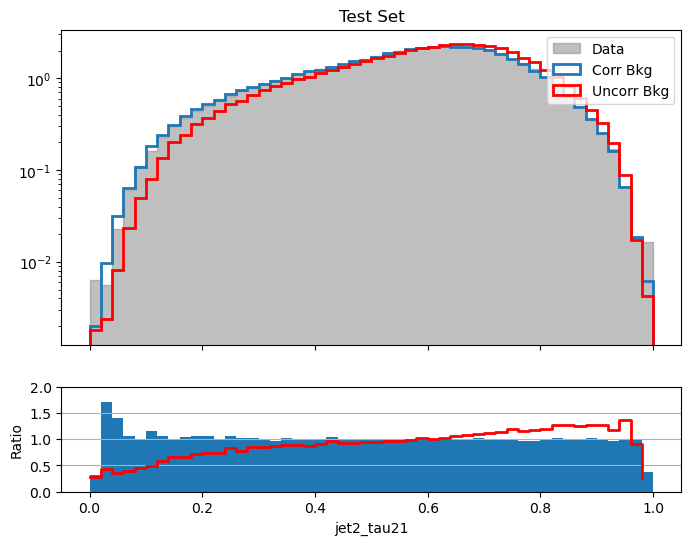

In [59]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [60]:
trainer.stepForward()

## jet2 tau32

Training flow bkgFlow_step6_jet2_tau32


Loss: 0.7231109666824341, p = 38: 100%|██████████| 1000/1000 [02:43<00:00,  6.10it/s]


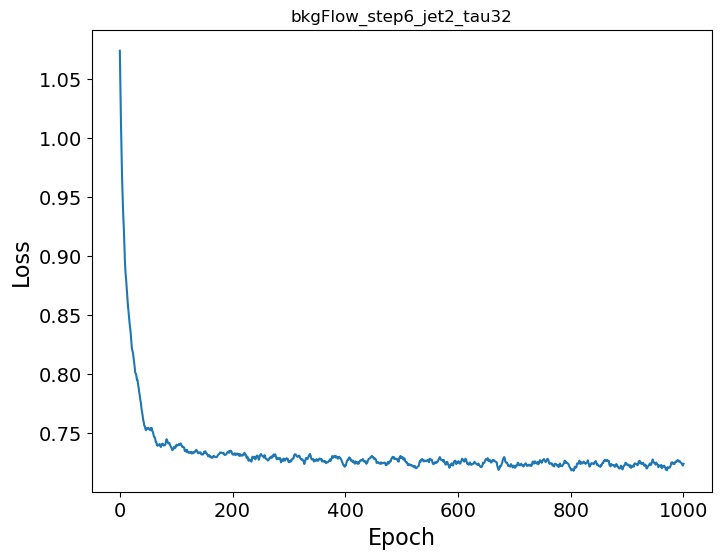

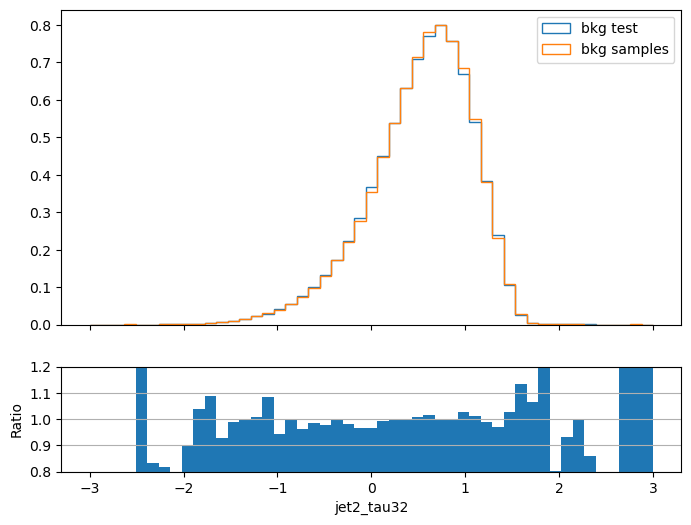

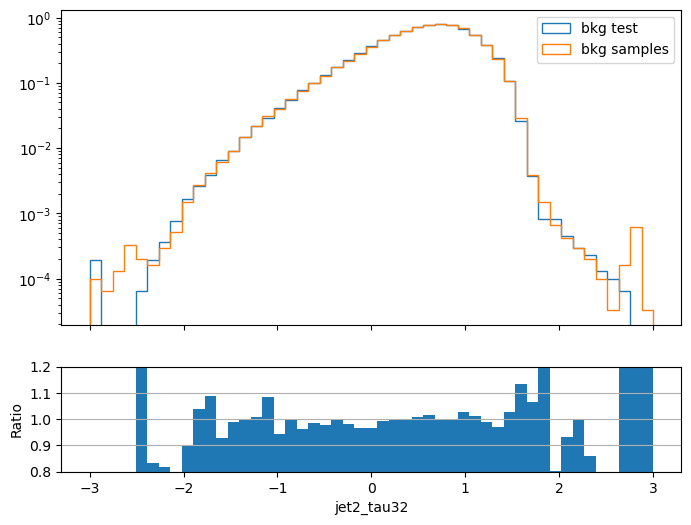

In [62]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_jet2_tau32


Loss: 0.7878976011276245, p = 66: 100%|██████████| 1000/1000 [02:42<00:00,  6.14it/s]


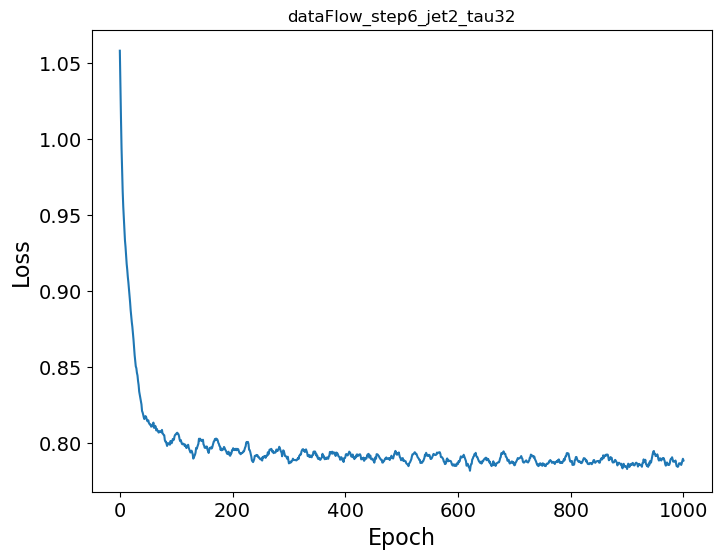

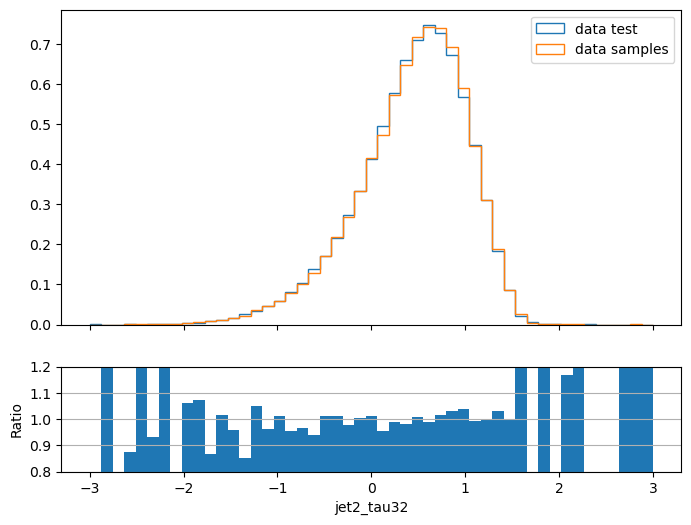

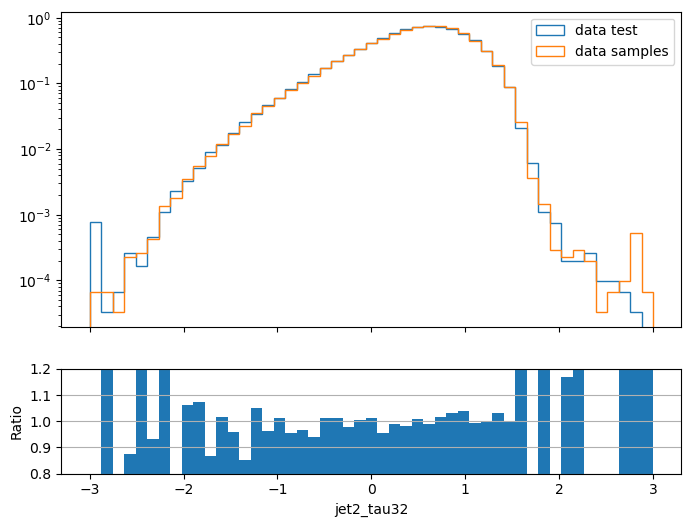

In [63]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:00<00:00, 45.91it/s]


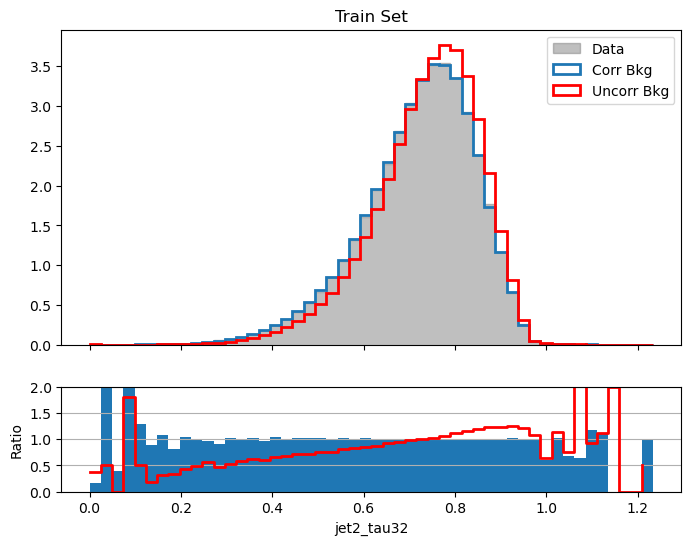

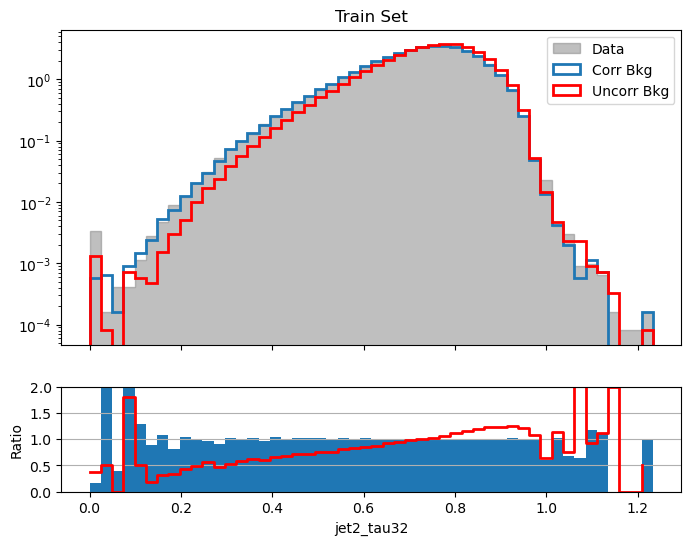

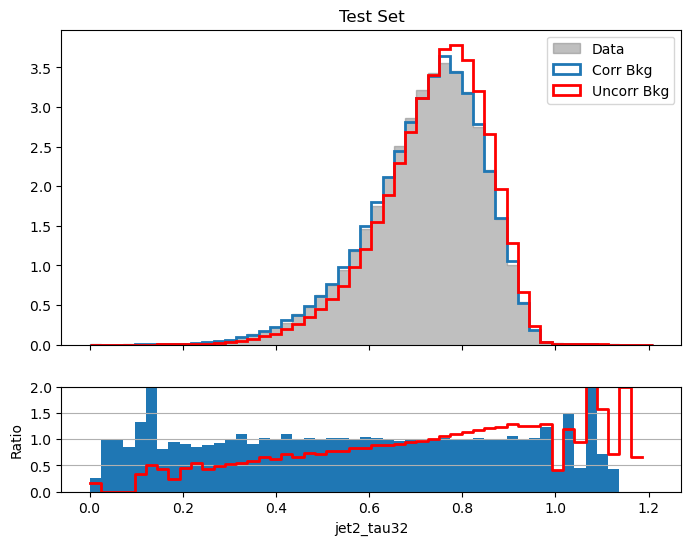

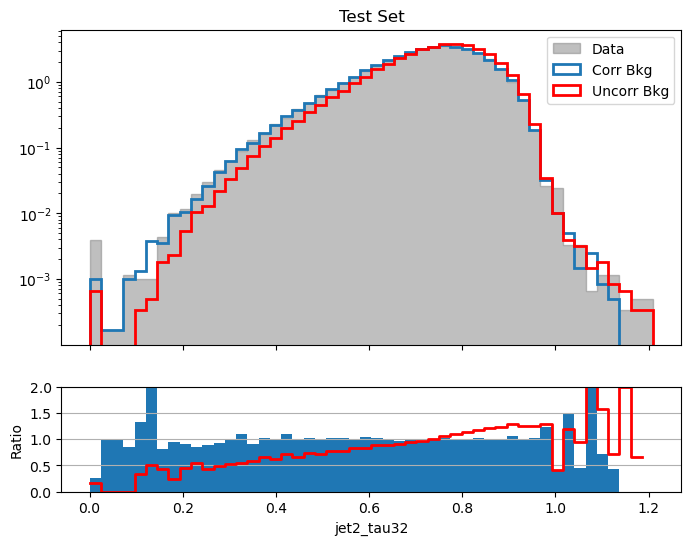

In [64]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [65]:
trainer.stepForward()

## jet2 tau43

Training flow bkgFlow_step7_jet2_tau43


Loss: 0.43260083854198456, p = 0: 100%|██████████| 1500/1500 [05:10<00:00,  4.83it/s]  


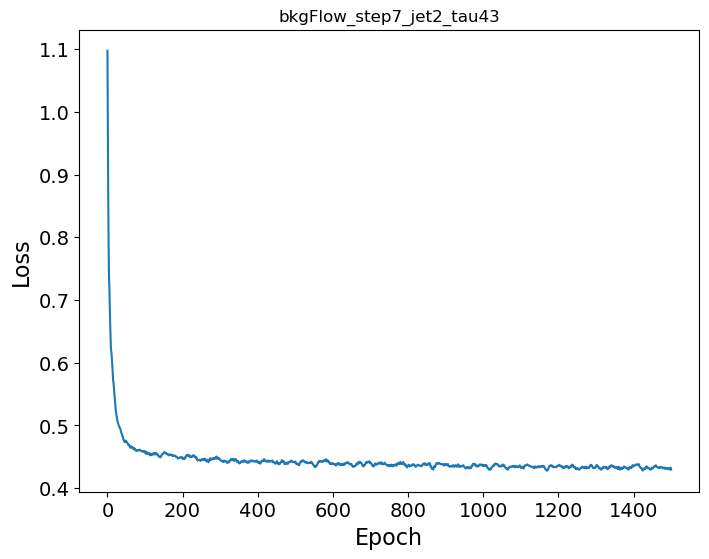

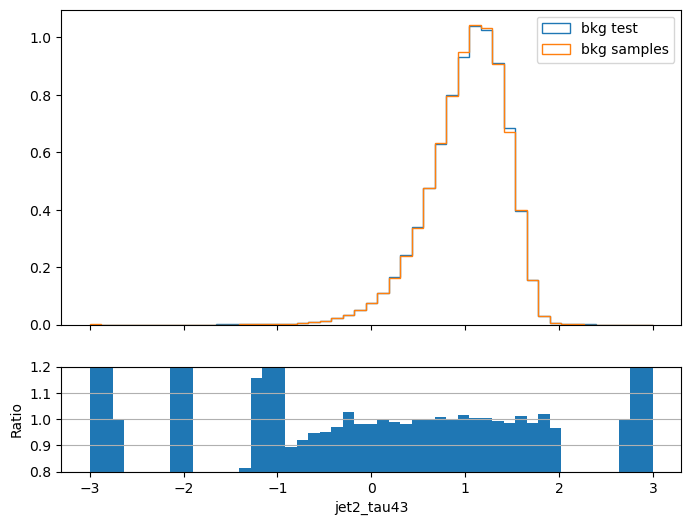

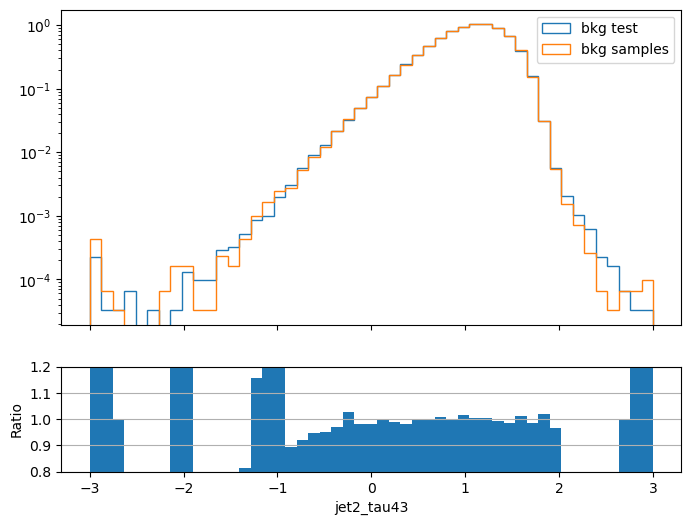

In [66]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step7_jet2_tau43


Loss: 0.49788018226623537, p = 147: 100%|██████████| 1500/1500 [05:08<00:00,  4.86it/s]


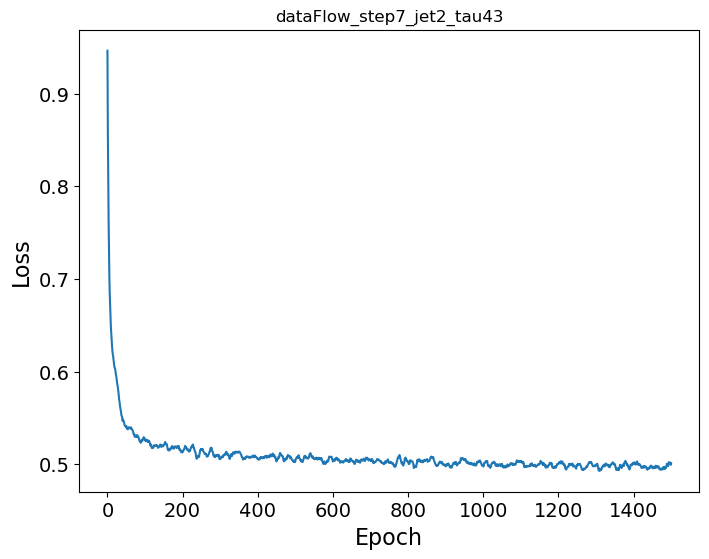

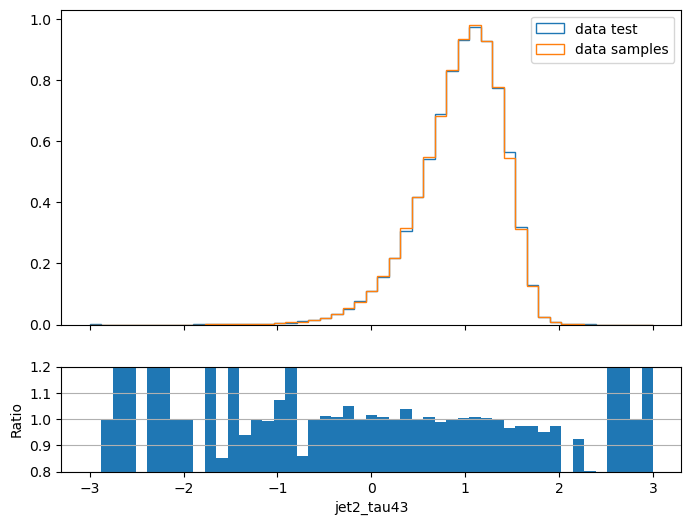

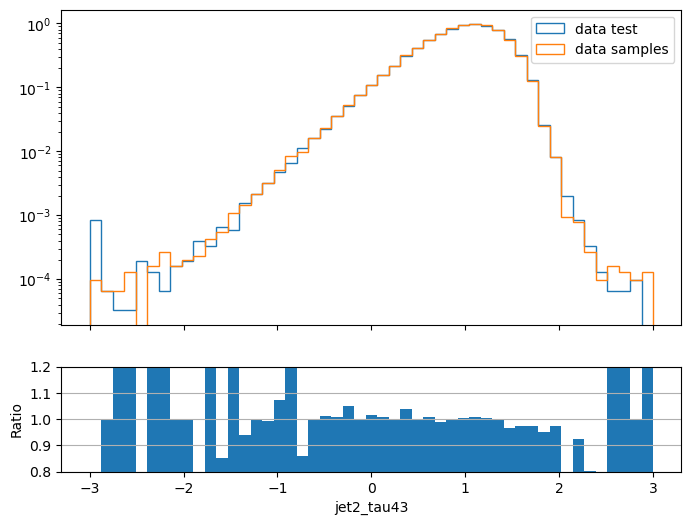

In [67]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 26/26 [00:02<00:00, 11.05it/s]


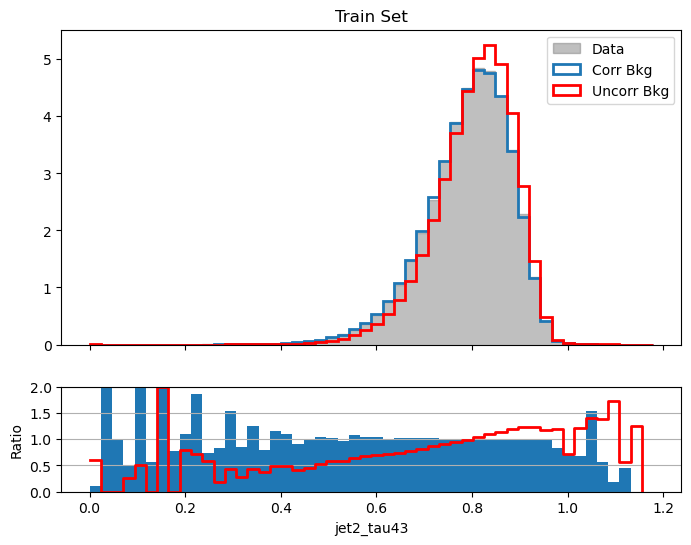

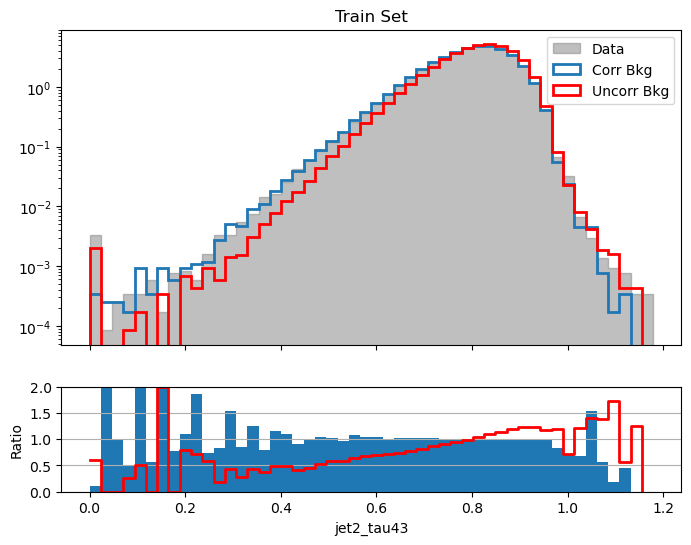

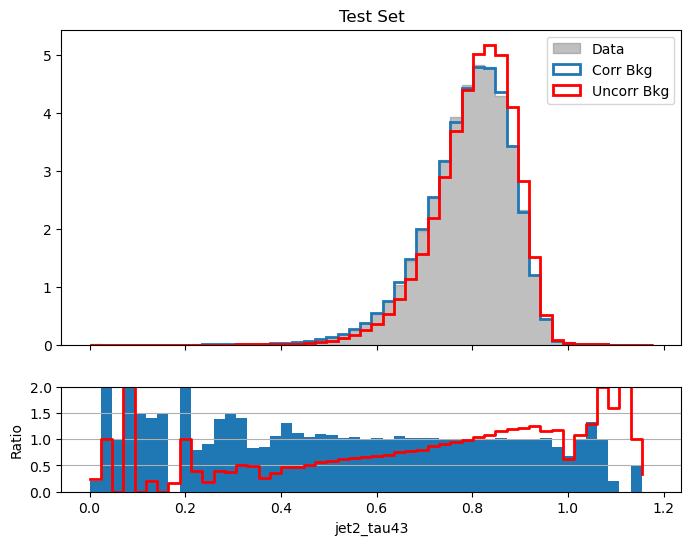

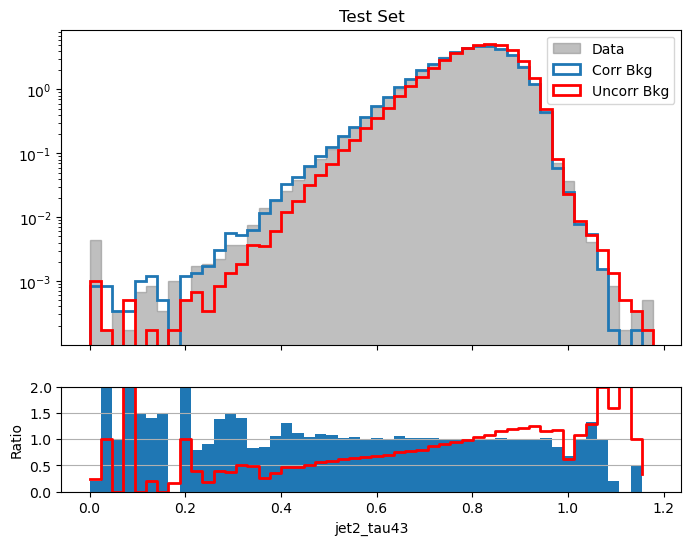

In [68]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])